# 📊 Clase 6 — Visualización de datos con Matplotlib
## Unidad: Visualización de datos

**Situación:** Desarrollas un dashboard exploratorio de ventas para una empresa de retail. La dirección comercial necesita visualizar comparativamente los volúmenes de ventas por trimestre y región, junto con la evolución mensual — todo en una sola figura exportable.

**Objetivos:**
- Crear gráficos con la **interfaz funcional `pyplot`** de forma correcta
- Dominar el **modelo orientado a objetos (OO)**: `Figure`, `Axes`, `Axis`, `Artist`
- Comparar `pyplot` vs OO: cuándo usar cada uno
- Encapsular visualizaciones en **funciones reutilizables**
- Construir **subgráficos** con `plt.subplots(nrows, ncols)` y `.flat`
- Exportar gráficos con `fig.savefig()`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print('✅ Librerías cargadas')
import matplotlib
print(f'Matplotlib {matplotlib.__version__}')

✅ Librerías cargadas
Matplotlib 3.11.0


---
## PARTE 1 — Interfaz funcional `pyplot`

### 1.1 ¿Cómo funciona pyplot internamente?

In [2]:
# Tabla de arquitectura — slide 7
tabla_arq = pd.DataFrame({
    'Componente': ['Figura (figure)','Ejes (axes)','Datos','Metadatos'],
    'Descripción': [
        'El lienzo o espacio donde se dibuja el gráfico.',
        'Área dentro de la figura donde se representa la visualización.',
        'Serie de puntos, líneas o barras a representar.',
        'Título, etiquetas de ejes, leyendas, grillas.'
    ]
})
print('=== Arquitectura de un gráfico pyplot ===')
print(tabla_arq.to_string(index=False))
print()
print('Nota: pyplot crea la figura y los ejes en segundo plano.')
print('Cada instrucción (plot, title, xlabel...) los va completando.')

=== Arquitectura de un gráfico pyplot ===
     Componente                                                    Descripción
Figura (figure)                El lienzo o espacio donde se dibuja el gráfico.
    Ejes (axes) Área dentro de la figura donde se representa la visualización.
          Datos                Serie de puntos, líneas o barras a representar.
      Metadatos                  Título, etiquetas de ejes, leyendas, grillas.

Nota: pyplot crea la figura y los ejes en segundo plano.
Cada instrucción (plot, title, xlabel...) los va completando.


### 1.2 Ejemplo pyplot — código exacto de la presentación

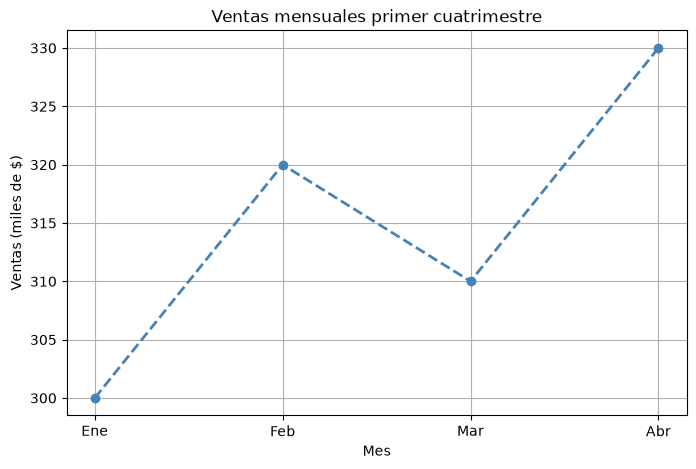

In [3]:
# Código exacto de la presentación — slide 8
import matplotlib.pyplot as plt

meses  = ['Ene', 'Feb', 'Mar', 'Abr']
ventas = [300, 320, 310, 330]

# Crear figura y grafico
plt.figure(figsize=(8, 5))
# Definimos tamaño en pulgadas
plt.plot(meses, ventas, color='steelblue', marker='o', linestyle='--', linewidth=2)

# Agregar metadatos
plt.title('Ventas mensuales primer cuatrimestre')
plt.xlabel('Mes')
plt.ylabel('Ventas (miles de $)')
plt.grid(True)

# Mostrar la figura
plt.show()

In [4]:
# Explicaciones clave — slide 9
print('Parámetros usados en el ejemplo:')
print("  marker='o'     → visualiza cada punto individual")
print("  linestyle='--' → estilo discontinuo a la línea")
print("  linewidth=2    → controla el grosor del trazo")
print("  color='steelblue' → color de la línea")

Parámetros usados en el ejemplo:
  marker='o'     → visualiza cada punto individual
  linestyle='--' → estilo discontinuo a la línea
  linewidth=2    → controla el grosor del trazo
  color='steelblue' → color de la línea


In [5]:
# Tabla de tipos de gráficos — slide 10
tabla_tipos = pd.DataFrame({
    'Función':     ['plot()','bar(), barh()','scatter()','hist()','pie()'],
    'Uso típico':  [
        'Series temporales, líneas',
        'Comparaciones categóricas',
        'Relaciones entre dos variables',
        'Distribuciones de frecuencia',
        'Proporciones (con reservas de uso)'
    ]
})
print(tabla_tipos.to_string(index=False))

      Función                         Uso típico
       plot()          Series temporales, líneas
bar(), barh()          Comparaciones categóricas
    scatter()     Relaciones entre dos variables
       hist()       Distribuciones de frecuencia
        pie() Proporciones (con reservas de uso)


### 1.3 Buenas prácticas y errores comunes con pyplot

In [6]:
# Tabla de errores comunes — slide 12
tabla_err = pd.DataFrame({
    'Error': ['El gráfico no se muestra',
              'Los gráficos se superponen al ejecutar varias veces',
              'Texto ilegible o cortado'],
    'Causa probable': ['Olvido de plt.show()',
                       'Estado persistente de la figura implícita',
                       'Tamaño por defecto muy pequeño'],
    'Solución recomendada': [
        'Incluirlo al final del bloque de código.',
        'Usar plt.clf() o plt.close("all") entre ejecuciones.',
        'Usar figsize y evitar etiquetas largas.'
    ]
})
print(tabla_err.to_string(index=False))

                                              Error                            Causa probable                                 Solución recomendada
                           El gráfico no se muestra                      Olvido de plt.show()             Incluirlo al final del bloque de código.
Los gráficos se superponen al ejecutar varias veces Estado persistente de la figura implícita Usar plt.clf() o plt.close("all") entre ejecuciones.
                           Texto ilegible o cortado            Tamaño por defecto muy pequeño              Usar figsize y evitar etiquetas largas.


=== Demostración de limpieza de figuras ===


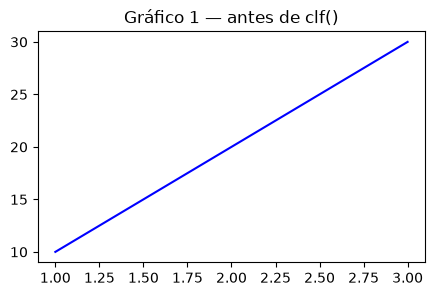

<Figure size 640x480 with 0 Axes>

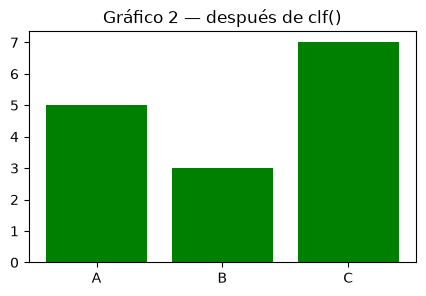

plt.close("all") ejecutado.


In [7]:
# Demostración: plt.clf() y plt.close() en acción
print('=== Demostración de limpieza de figuras ===')

# Gráfico 1
plt.figure(figsize=(5, 3))
plt.plot([1,2,3],[10,20,30], color='blue')
plt.title('Gráfico 1 — antes de clf()')
plt.show()

# Limpiar estado
plt.clf()   # limpia la figura actual

# Gráfico 2 — limpio, sin residuos
plt.figure(figsize=(5, 3))
plt.bar(['A','B','C'],[5,3,7], color='green')
plt.title('Gráfico 2 — después de clf()')
plt.show()

plt.close('all')  # cerrar todas las figuras abiertas
print('plt.close("all") ejecutado.')

---
## PARTE 2 — Modelo orientado a objetos (OO)

### 2.1 Arquitectura jerárquica

In [8]:
# Tabla de arquitectura OO — slide 15
tabla_oo = pd.DataFrame({
    'Componente': ['Figure','Axes','Axis','Artist'],
    'Descripción': [
        'Lienzo general donde se dibujan uno o varios gráficos.',
        'Recuadro o área dentro de la figura. Cada Axes tiene su propio sistema de coordenadas.',
        'Cada uno de los ejes X o Y en un Axes. Controla valores, tics y etiquetas.',
        'Cualquier objeto visible: títulos, textos, líneas, cuadros, leyendas, etc.'
    ]
})
print('=== Arquitectura OO de Matplotlib ===')
print(tabla_oo.to_string(index=False))

=== Arquitectura OO de Matplotlib ===
Componente                                                                            Descripción
    Figure                                 Lienzo general donde se dibujan uno o varios gráficos.
      Axes Recuadro o área dentro de la figura. Cada Axes tiene su propio sistema de coordenadas.
      Axis             Cada uno de los ejes X o Y en un Axes. Controla valores, tics y etiquetas.
    Artist             Cualquier objeto visible: títulos, textos, líneas, cuadros, leyendas, etc.


### 2.2 Gráfico OO — código exacto de la presentación

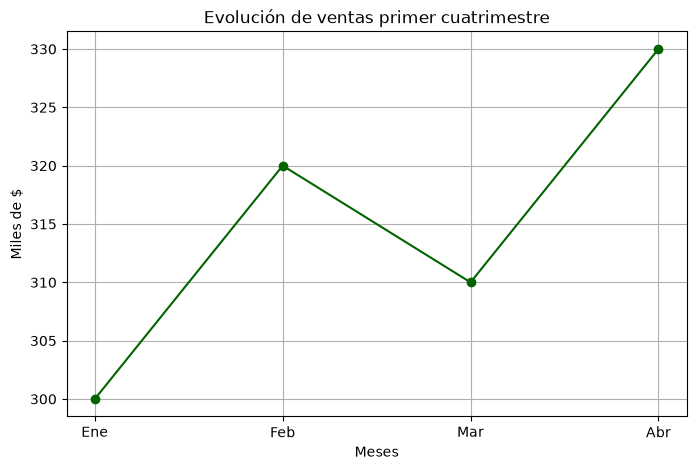

In [9]:
# Código exacto de la presentación — slide 16
import matplotlib.pyplot as plt

# Datos
meses  = ['Ene', 'Feb', 'Mar', 'Abr']
ventas = [300, 320, 310, 330]

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(8, 5))

# Dibujar en los ejes
ax.plot(meses, ventas, color='darkgreen', marker='o')

# Personalizar elementos
ax.set_title('Evolución de ventas primer cuatrimestre')
ax.set_xlabel('Meses')
ax.set_ylabel('Miles de $')
ax.grid(True)

# Mostrar
plt.show()

In [10]:
# Explicación del modelo OO — slide 17
print('=== Explicación del modelo OO ===')
print('fig → el lienzo general donde se dibuja todo')
print('ax  → el área específica del gráfico')
print()
print('Métodos de ax que controlan cada aspecto:')
metodos = [
    ('ax.plot()', 'Trazar línea o puntos'),
    ('ax.bar()',  'Gráfico de barras'),
    ('ax.set_title()', 'Título del área de dibujo'),
    ('ax.set_xlabel()', 'Etiqueta eje X'),
    ('ax.set_ylabel()', 'Etiqueta eje Y'),
    ('ax.legend()',     'Leyenda'),
    ('ax.grid(True)',   'Cuadrícula'),
    ('ax.set_xlim()',   'Límites del eje X'),
    ('ax.set_ylim()',   'Límites del eje Y'),
]
for metodo, desc in metodos:
    print(f'  {metodo:<22} → {desc}')

=== Explicación del modelo OO ===
fig → el lienzo general donde se dibuja todo
ax  → el área específica del gráfico

Métodos de ax que controlan cada aspecto:
  ax.plot()              → Trazar línea o puntos
  ax.bar()               → Gráfico de barras
  ax.set_title()         → Título del área de dibujo
  ax.set_xlabel()        → Etiqueta eje X
  ax.set_ylabel()        → Etiqueta eje Y
  ax.legend()            → Leyenda
  ax.grid(True)          → Cuadrícula
  ax.set_xlim()          → Límites del eje X
  ax.set_ylim()          → Límites del eje Y


### 2.3 Comparativa pyplot vs OO — slide 19

In [11]:
tabla_comp = pd.DataFrame({
    'Característica': ['Figura implícita','Modularidad','Escalabilidad',
                       'Uso en proyectos complejos','Sintaxis'],
    'pyplot (funcional)': ['Sí','Baja','Limitada','No recomendado',
                            'plt.plot(), plt.title()...'],
    'Modelo OO (estructurado)': ['No (requiere definición)','Alta','Completa',
                                  'Recomendado','ax.plot(), ax.set_title()']
})
print('=== Comparativa técnica: pyplot vs OO ===')
print(tabla_comp.to_string(index=False))
print()
print('Recomendación: usa pyplot para exploración rápida.')
print('Usa OO para reportes, funciones reutilizables y subgráficos.')

=== Comparativa técnica: pyplot vs OO ===
            Característica         pyplot (funcional)  Modelo OO (estructurado)
          Figura implícita                         Sí  No (requiere definición)
               Modularidad                       Baja                      Alta
             Escalabilidad                   Limitada                  Completa
Uso en proyectos complejos             No recomendado               Recomendado
                  Sintaxis plt.plot(), plt.title()... ax.plot(), ax.set_title()

Recomendación: usa pyplot para exploración rápida.
Usa OO para reportes, funciones reutilizables y subgráficos.


### 2.4 Función reutilizable — código exacto de la presentación

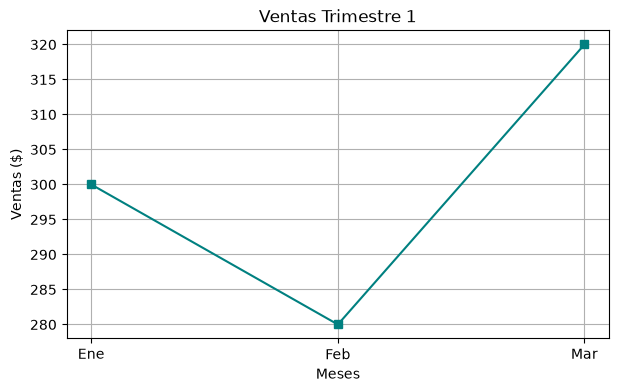

In [12]:
# Código exacto de la presentación — slide 20
def grafico_ventas(meses, ventas, titulo):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(meses, ventas, marker='s', color='teal')
    ax.set_title(titulo)
    ax.set_xlabel('Meses')
    ax.set_ylabel('Ventas ($)')
    ax.grid(True)
    return fig

# Llamado de la función
grafico_ventas(['Ene', 'Feb', 'Mar'], [300, 280, 320], 'Ventas Trimestre 1')
plt.show()

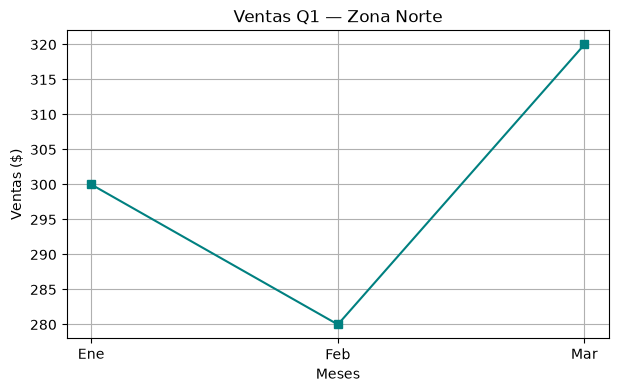

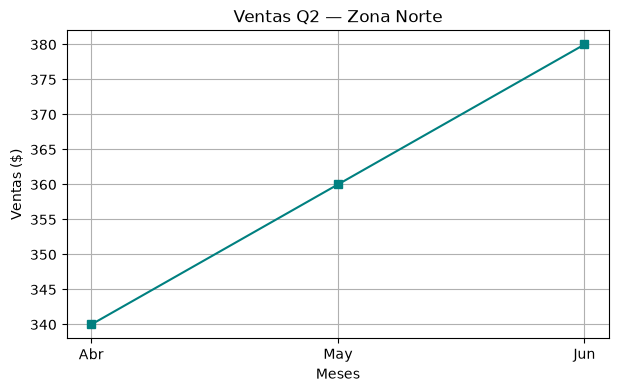

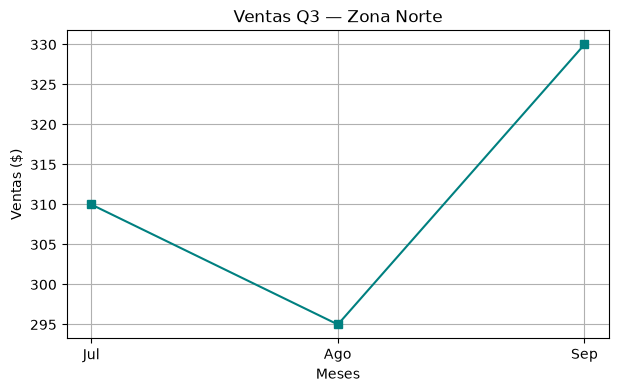

Misma función, distintos datos — código reutilizable ✅


In [13]:
# Demostración de la ventaja de la función reutilizable
# Llamar la misma función con diferentes datos
trimestres = [
    (['Ene','Feb','Mar'], [300, 280, 320], 'Ventas Q1 — Zona Norte'),
    (['Abr','May','Jun'], [340, 360, 380], 'Ventas Q2 — Zona Norte'),
    (['Jul','Ago','Sep'], [310, 295, 330], 'Ventas Q3 — Zona Norte'),
]

for meses_t, ventas_t, titulo_t in trimestres:
    grafico_ventas(meses_t, ventas_t, titulo_t)
    plt.show()

print('Misma función, distintos datos — código reutilizable ✅')

### ✏️ Ejercicio 2:

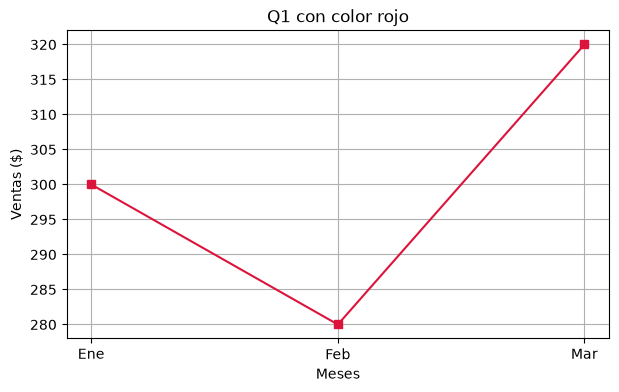

1. 
2. 


In [14]:
# ✏️ 1. ¿Qué ventajas ofrece el modelo OO frente a pyplot en visualizaciones complejas?
c1 = ""

# ✏️ 2. ¿Cuál es la estructura jerárquica de Matplotlib y qué rol cumple cada componente?
c2 = ""

# ✏️ 3. Modifica la función grafico_ventas() para añadir el parámetro color:
def grafico_ventas_v2(meses, ventas, titulo, color='teal'):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(meses, ventas, marker='s', color=color)  # ← ahora acepta color
    ax.set_title(titulo)
    ax.set_xlabel('Meses')
    ax.set_ylabel('Ventas ($)')
    ax.grid(True)
    return fig

grafico_ventas_v2(['Ene','Feb','Mar'], [300, 280, 320], 'Q1 con color rojo', color='crimson')
plt.show()

print(f'1. {c1}')
print(f'2. {c2}')

---
## PARTE 3 — Figuras y subgráficos (`subplots`)

### 3.1 Fundamentos de `plt.subplots()`

In [15]:
# Código exacto de la presentación — slide 25
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

print(f'Tipo de fig:  {type(fig)}')
print(f'Tipo de axs:  {type(axs)}')
print(f'Shape de axs: {axs.shape}  → arreglo 2×2')
print(f'axs[0,0]:     {type(axs[0,0])}  → Axes superior izquierdo')
print(f'axs.flat:     iterador lineal → [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]')

plt.close(fig)  # cerrar la figura vacía

print()
print('Tabla de errores con subgráficos:')
tabla_sub_err = pd.DataFrame({
    'Error': ['Índices incorrectos al usar axs[i]',
              'Etiquetas y títulos se superponen',
              'Pérdida de proporción visual'],
    'Causa': ['Arreglo 2D sin recorrer con .flat',
               'Falta de ajuste en el diseño',
               'Tamaño de figura inadecuado'],
    'Solución': ['Usar axs.flat para iterar linealmente',
                  'Aplicar tight_layout() y ajustar márgenes',
                  'Ajustar figsize y cantidad de filas/columnas']
})
print(tabla_sub_err.to_string(index=False))

Tipo de fig:  <class 'matplotlib.figure.Figure'>
Tipo de axs:  <class 'numpy.ndarray'>
Shape de axs: (2, 2)  → arreglo 2×2
axs[0,0]:     <class 'matplotlib.axes._axes.Axes'>  → Axes superior izquierdo
axs.flat:     iterador lineal → [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

Tabla de errores con subgráficos:
                             Error                             Causa                                     Solución
Índices incorrectos al usar axs[i] Arreglo 2D sin recorrer con .flat        Usar axs.flat para iterar linealmente
 Etiquetas y títulos se superponen      Falta de ajuste en el diseño    Aplicar tight_layout() y ajustar márgenes
      Pérdida de proporción visual       Tamaño de figura inadecuado Ajustar figsize y cantidad de filas/columnas


### 3.2 Ejemplo aplicado: comparación regional de ventas (código exacto)

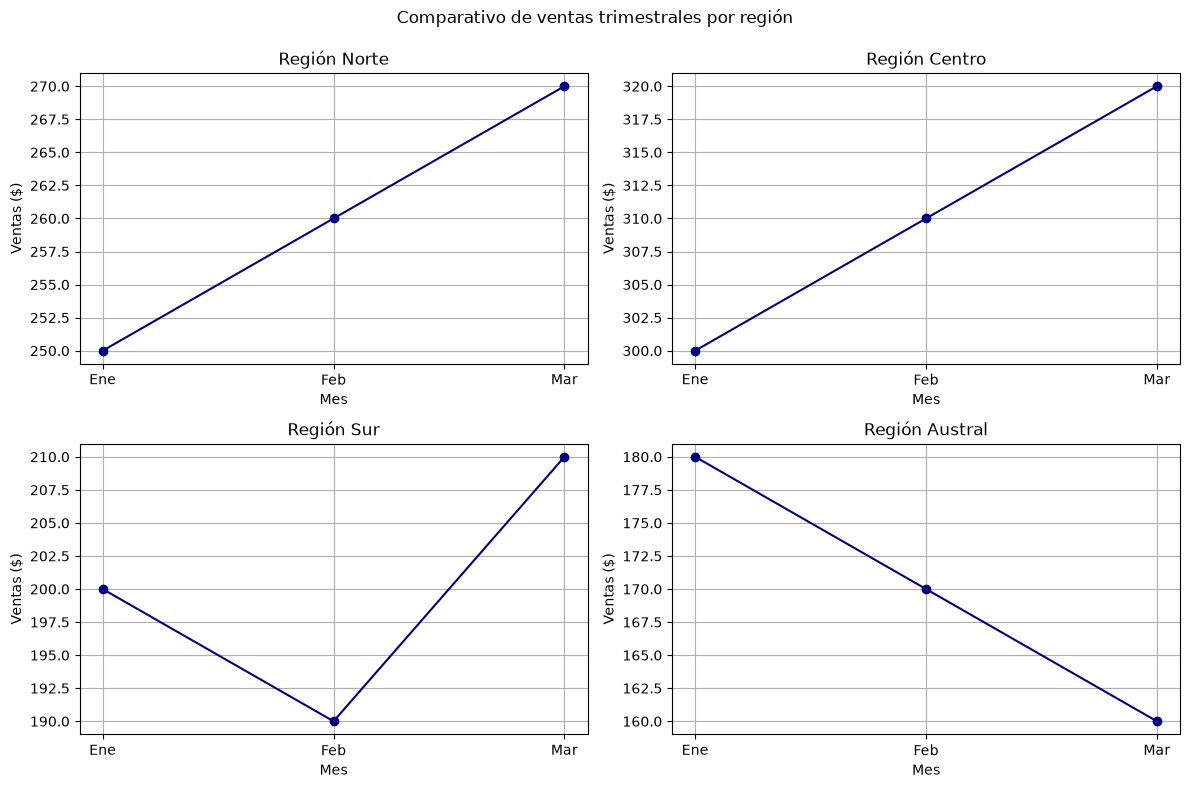

In [16]:
# Código exacto de la presentación — slide 26
import matplotlib.pyplot as plt

meses = ['Ene', 'Feb', 'Mar']
datos = {
    'Norte':   [250, 260, 270],
    'Centro':  [300, 310, 320],
    'Sur':     [200, 190, 210],
    'Austral': [180, 170, 160]
}

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
regiones = list(datos.keys())

for i, ax in enumerate(axs.flat):
    region = regiones[i]
    ax.plot(meses, datos[region], marker='o', color='navy')
    ax.set_title(f'Región {region}')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Ventas ($)')
    ax.grid(True)

fig.suptitle('Comparativo de ventas trimestrales por región')
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

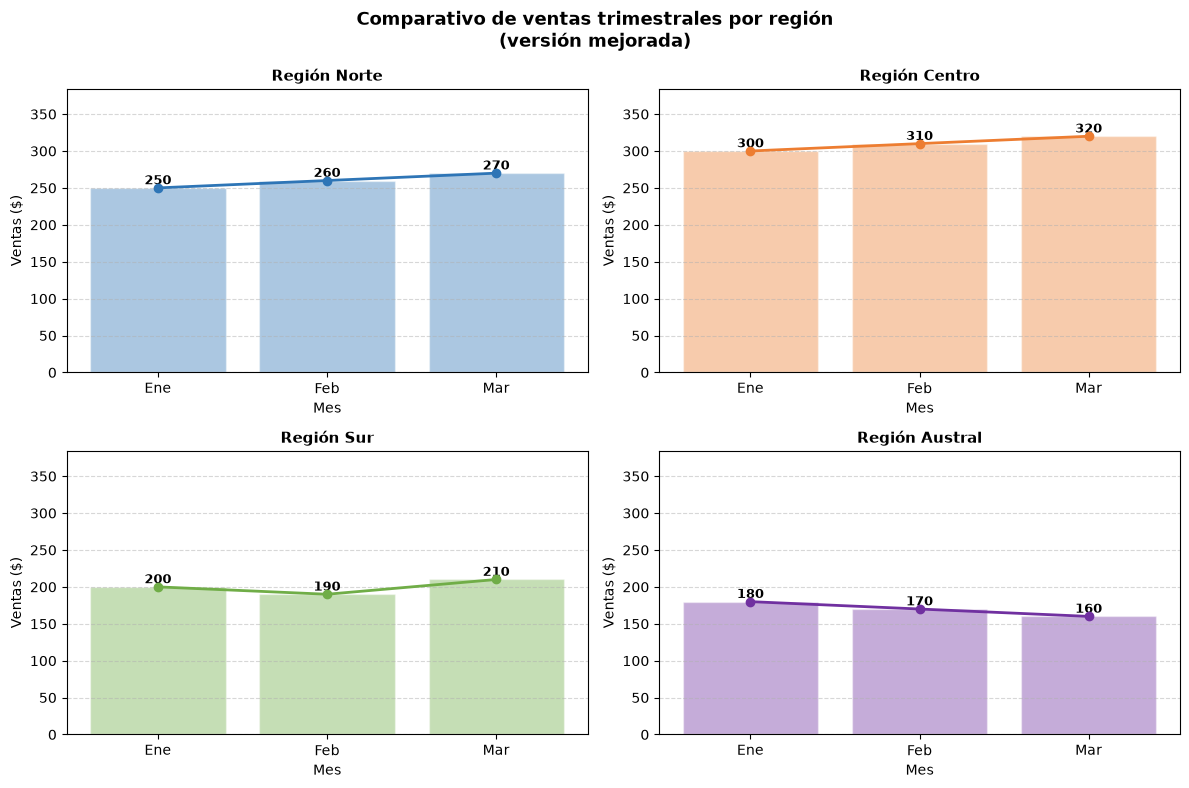

In [17]:
# Versión mejorada con colores diferenciados y barras
colores = ['#2E75B6', '#ED7D31', '#70AD47', '#7030A0']

fig2, axs2 = plt.subplots(2, 2, figsize=(12, 8))
regiones = list(datos.keys())

for i, (ax, color) in enumerate(zip(axs2.flat, colores)):
    region = regiones[i]
    valores = datos[region]
    # Línea + barras
    ax.bar(meses, valores, color=color, alpha=0.4, edgecolor='white')
    ax.plot(meses, valores, marker='o', color=color, linewidth=2, zorder=5)
    ax.set_title(f'Región {region}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Ventas ($)')
    ax.set_ylim(0, max(max(v) for v in datos.values()) * 1.2)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    # Anotar valores
    for j, v in enumerate(valores):
        ax.text(j, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

fig2.suptitle('Comparativo de ventas trimestrales por región\n(versión mejorada)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

### 3.3 Layouts de subgráficos disponibles

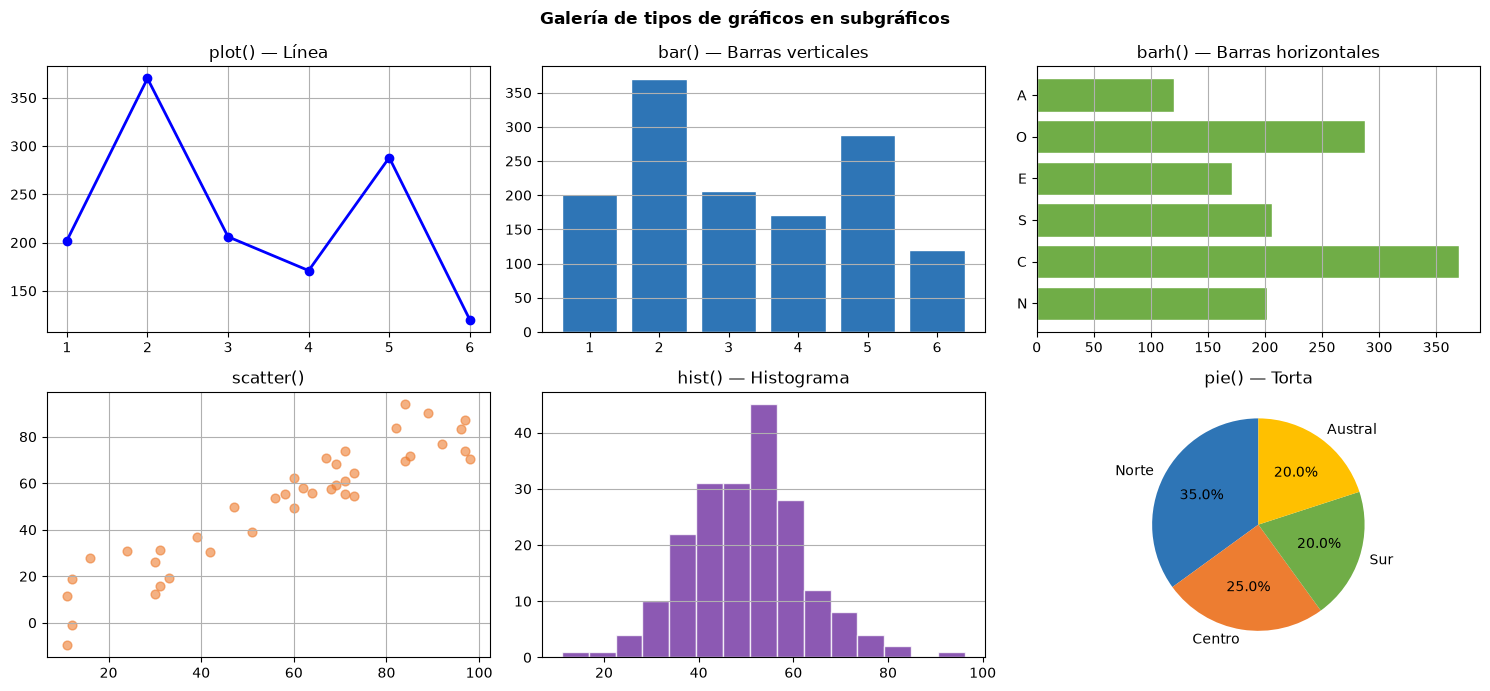

In [18]:
np.random.seed(42)
x = np.arange(1, 7)
y = np.random.randint(100, 400, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Galería de tipos de gráficos en subgráficos', fontweight='bold', fontsize=12)

# plot()
axes[0,0].plot(x, y, 'b-o', linewidth=2)
axes[0,0].set_title('plot() — Línea')
axes[0,0].grid(True)

# bar()
axes[0,1].bar(x, y, color='#2E75B6', edgecolor='white')
axes[0,1].set_title('bar() — Barras verticales')
axes[0,1].grid(True, axis='y')

# barh()
regiones = ['N','C','S','E','O','A']
axes[0,2].barh(regiones, y, color='#70AD47', edgecolor='white')
axes[0,2].set_title('barh() — Barras horizontales')
axes[0,2].grid(True, axis='x')

# scatter()
x2 = np.random.randint(10, 100, 40)
y2 = x2 * 0.9 + np.random.normal(0, 10, 40)
axes[1,0].scatter(x2, y2, color='#ED7D31', alpha=0.6, s=40)
axes[1,0].set_title('scatter()')
axes[1,0].grid(True)

# hist()
datos_hist = np.random.normal(50, 12, 200)
axes[1,1].hist(datos_hist, bins=15, color='#7030A0', edgecolor='white', alpha=0.8)
axes[1,1].set_title('hist() — Histograma')
axes[1,1].grid(True, axis='y')

# pie()
sizes = [35, 25, 20, 20]
labels_p = ['Norte','Centro','Sur','Austral']
axes[1,2].pie(sizes, labels=labels_p, autopct='%1.1f%%',
              startangle=90, colors=['#2E75B6','#ED7D31','#70AD47','#FFC000'])
axes[1,2].set_title('pie() — Torta')

plt.tight_layout()
plt.show()

### ✏️ Ejercicio 3:

In [19]:
# ✏️ 3. ¿Cómo se usan los subgráficos para comparar diferentes conjuntos de datos?
c3 = ""

# ✏️ 4. ¿Qué errores debes evitar al crear múltiples subgráficos?
c4 = ""

# ✏️ ¿Por qué es necesario plt.subplots_adjust(top=0.9) junto a tight_layout?
r_adjust = ""

print(f'3. Subgráficos: {c3}')
print(f'4. Errores:     {c4}')
print(f'adjust(top):    {r_adjust}')

3. Subgráficos: 
4. Errores:     
adjust(top):    


---
## PARTE 4 — Actividad guiada: Reporte visual comparativo

### Función `reporte_regional()` — código exacto de la presentación

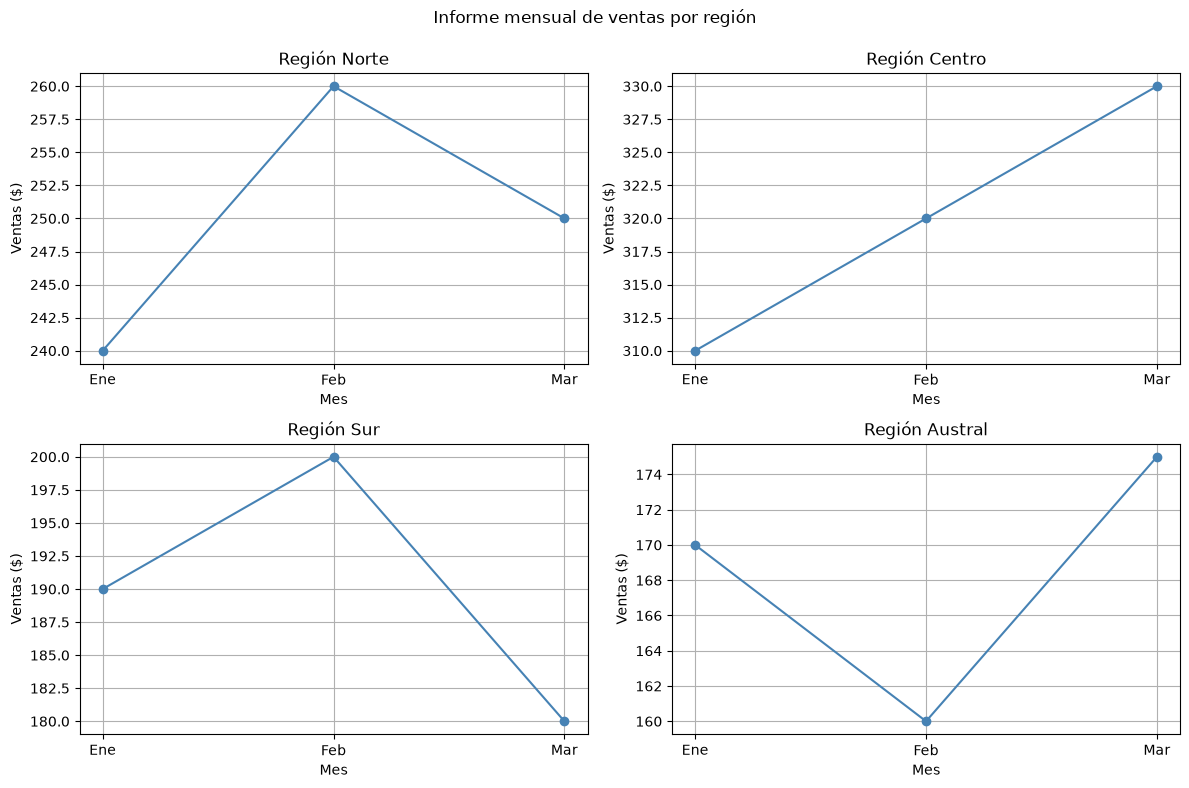

In [20]:
# Código exacto de la presentación — slide 33
import matplotlib.pyplot as plt

def reporte_regional(datos):
    regiones = list(datos.keys())
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    for i, ax in enumerate(axs.flat):
        region = regiones[i]
        meses  = list(datos[region].keys())
        ventas = list(datos[region].values())

        ax.plot(meses, ventas, marker='o', color='steelblue')
        ax.set_title(f'Región {region}')
        ax.set_xlabel('Mes')
        ax.set_ylabel('Ventas ($)')
        ax.grid(True)

    fig.suptitle('Informe mensual de ventas por región')
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Simulación de datos
datos_ventas = {
    'Norte':   {'Ene': 240, 'Feb': 260, 'Mar': 250},
    'Centro':  {'Ene': 310, 'Feb': 320, 'Mar': 330},
    'Sur':     {'Ene': 190, 'Feb': 200, 'Mar': 180},
    'Austral': {'Ene': 170, 'Feb': 160, 'Mar': 175}
}

reporte_regional(datos_ventas)

### Versión extendida con exportación

✅ Gráfico guardado como reporte_ventas_q1.png


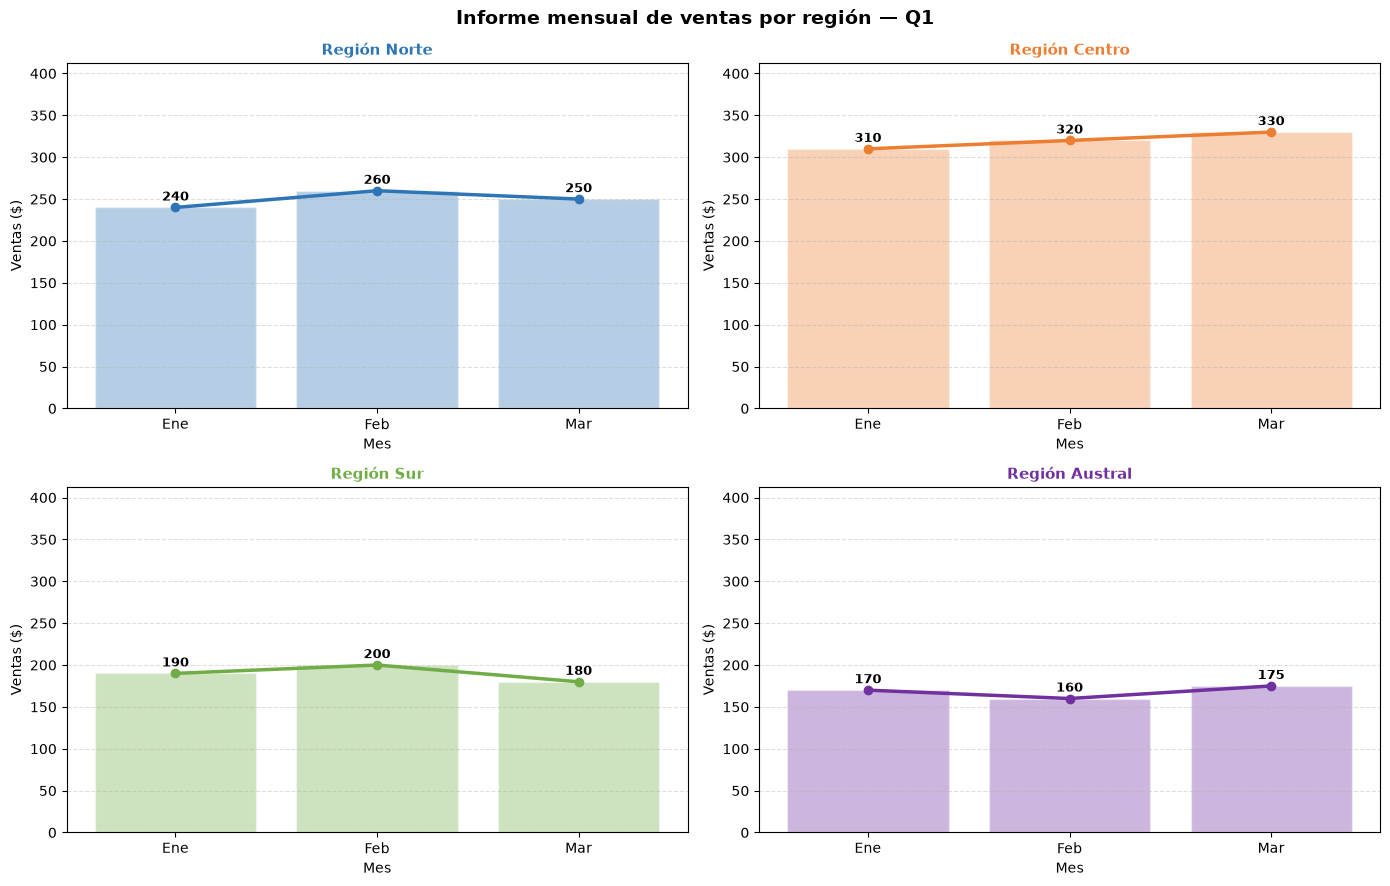

In [24]:
# Función extendida — buenas prácticas del slide 31-32
def reporte_regional_pro(datos, titulo_general='Informe mensual de ventas',
                          guardar=False, nombre_archivo='reporte_ventas.png'):
    """
    Genera un reporte comparativo de ventas por región.
    
    Parámetros:
    -----------
    datos : dict
        Diccionario {región: {mes: ventas}}
    titulo_general : str
        Título de la figura completa
    guardar : bool
        Si True, guarda el gráfico como imagen
    nombre_archivo : str
        Nombre del archivo de salida (PNG)
    
    Retorna:
    --------
    fig : matplotlib.figure.Figure
    """
    colores_reg = ['#2E75B6', '#ED7D31', '#70AD47', '#7030A0']
    regiones    = list(datos.keys())

    fig, axs = plt.subplots(2, 2, figsize=(14, 9))

    for i, (ax, color) in enumerate(zip(axs.flat, colores_reg)):
        region  = regiones[i]
        meses_r = list(datos[region].keys())
        ventas_r = list(datos[region].values())

        # Barra + línea combinadas
        ax.bar(meses_r, ventas_r, color=color, alpha=0.35, edgecolor='white', label='Ventas')
        ax.plot(meses_r, ventas_r, marker='o', color=color, linewidth=2.5, zorder=5)

        # Personalización
        ax.set_title(f'Región {region}', fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Mes')
        ax.set_ylabel('Ventas ($)')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        ax.set_ylim(0, max(max(v.values()) for v in datos.values()) * 1.25)

        # Anotaciones de valor
        for j, v in enumerate(ventas_r):
            ax.annotate(f'{v}', xy=(j, v), xytext=(0, 5),
                        textcoords='offset points', ha='center',
                        fontsize=9, fontweight='bold')

    fig.suptitle(titulo_general, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)

    if guardar:
        fig.savefig(nombre_archivo, dpi=150, bbox_inches='tight')
        print(f'✅ Gráfico guardado como {nombre_archivo}')

    plt.show()
    return fig


# Usar la función con datos del slide
fig_reporte = reporte_regional_pro(
    datos_ventas,
    titulo_general='Informe mensual de ventas por región — Q1',
    guardar=True,
    nombre_archivo='reporte_ventas_q1.png'
)

### Probar con datos del próximo trimestre

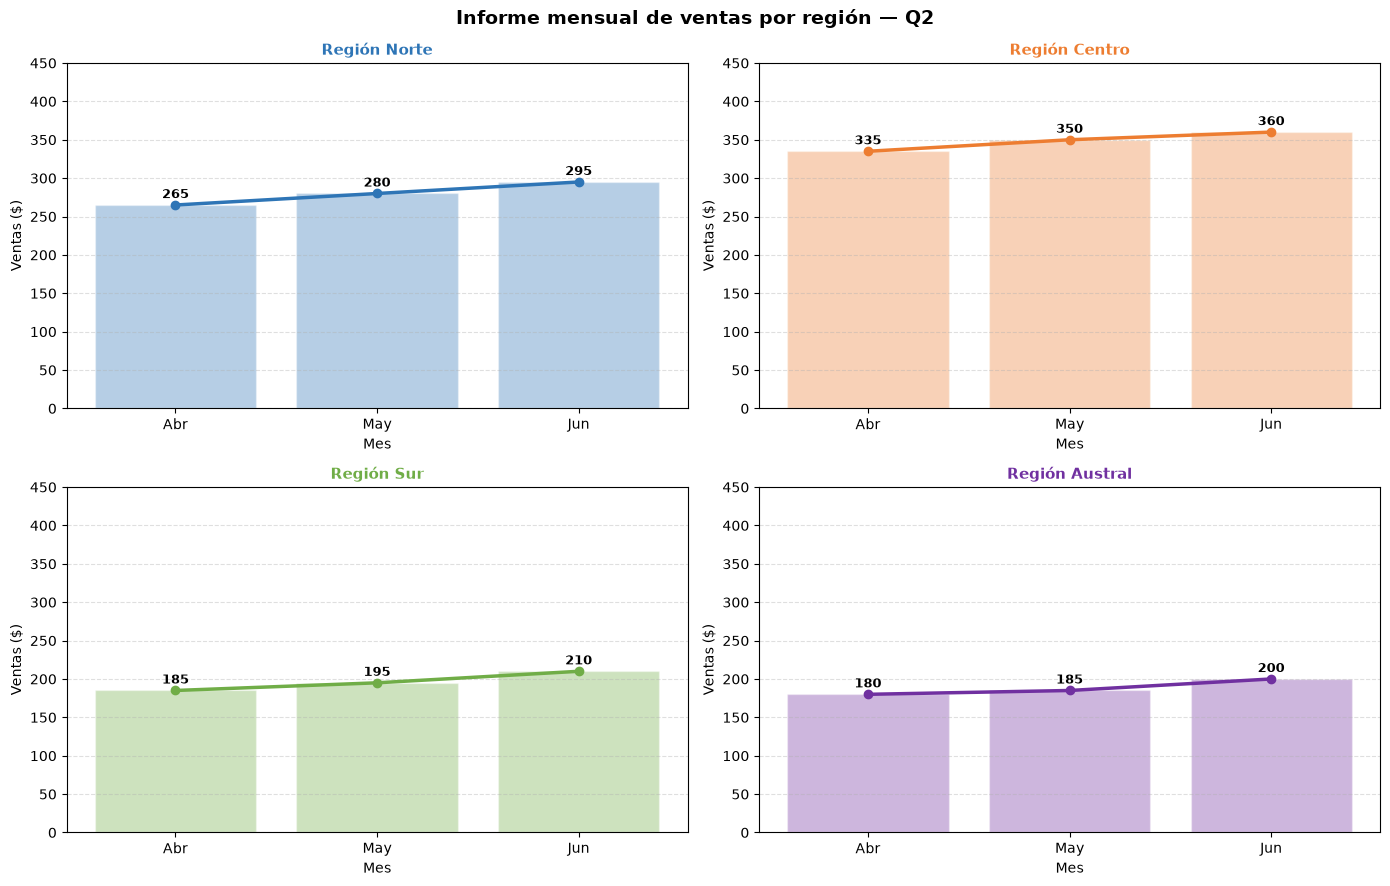

✅ La función reutilizable funciona con diferentes datos sin modificar el código


In [25]:
# Actualizar la función con Q2 — misma función, distintos datos
datos_q2 = {
    'Norte':   {'Abr': 265, 'May': 280, 'Jun': 295},
    'Centro':  {'Abr': 335, 'May': 350, 'Jun': 360},
    'Sur':     {'Abr': 185, 'May': 195, 'Jun': 210},
    'Austral': {'Abr': 180, 'May': 185, 'Jun': 200}
}

reporte_regional_pro(
    datos_q2,
    titulo_general='Informe mensual de ventas por región — Q2',
    guardar=False
)
print('✅ La función reutilizable funciona con diferentes datos sin modificar el código')

### ✏️ Preguntas de cierre (slide 36):

In [26]:
# ✏️ 1. ¿Qué ventajas ofrece el modelo OO frente a pyplot en visualizaciones complejas?
p1 = ""

# ✏️ 2. ¿Cuál es la estructura jerárquica de Matplotlib y qué rol cumple cada componente?
p2 = ""

# ✏️ 3. ¿Cómo se usan los subgráficos para comparar diferentes conjuntos de datos?
p3 = ""

# ✏️ 4. ¿Qué errores comunes debes evitar al crear múltiples subgráficos en una misma figura?
p4 = ""

# ✏️ 5. ¿Cómo puedes reutilizar una visualización profesional en distintos contextos productivos?
p5 = ""

print('--- PREGUNTAS DE CIERRE ---')
for i, p in enumerate([p1, p2, p3, p4, p5], 1):
    print(f'{i}. {p}')

--- PREGUNTAS DE CIERRE ---
1. 
2. 
3. 
4. 
5. 


---
## 📋 Resumen de diferencias y buenas prácticas

### pyplot vs Modelo OO

| | pyplot (funcional) | Modelo OO (fig, ax) |
|-|-|-|
| Figura | Implícita (oculta) | Explícita (`fig, ax = plt.subplots()`) |
| Modularidad | Baja | Alta |
| Escalabilidad | Limitada | Completa |
| Subgráficos | `plt.subplot()` | `plt.subplots(n,m)` + `axs.flat` |
| Uso recomendado | Exploración rápida | Reportes y proyectos |

### Subgráficos con `plt.subplots()`

| Patrón | Código | Descripción |
|--------|--------|-------------|
| 1 fila, 2 cols | `fig, (ax1, ax2) = plt.subplots(1, 2)` | Desempacar directo |
| 2×2 con flat | `for ax in axs.flat:` | Iterar sin índices |
| Título global | `fig.suptitle('...')` | Título de la figura completa |
| Evitar solapamiento | `plt.tight_layout()` + `plt.subplots_adjust(top=0.9)` | Espacio para suptitle |
| Exportar | `fig.savefig('archivo.png', dpi=150, bbox_inches='tight')` | Alta calidad |

> 💡 **`axs.flat`** convierte el arreglo 2D de ejes en un iterador lineal — es la forma más limpia de recorrer subgráficos con `enumerate()`.

> 💡 **Funciones reutilizables** que reciben `datos` y retornan `fig` son el patrón profesional para reportes automáticos, alertas y dashboards.